# CSCI 3202: MANCALA PROJECT
## Parth Chudappa & Benjamin Willcutt

Libraries Used

In [4]:
import random
import time
import matplotlib.pyplot as plt
import copy
random.seed(12)


### Main Mancala Class


__init__ - Creates board array with pits and mancalas

play(pit) - takes stones from chosen pit, distributes counter-clockwise, captures opposite stones, handles extra turns

valid_move(pit) - Checks if selected pit has stones

winning_eval() - Returns True if either player's pits are empty

get_legal_moves_for_player(player) - Returns list of playable pits

clone() - Creates deep copy for AI search trees

display_board() - Prints current board state

random_move_generator() - Returns random legal move

In [5]:

class Mancala:
    def __init__(self, pits_per_player=6, stones_per_pit = 4):
        self.pits_per_player = pits_per_player
        self.board = [stones_per_pit] * ((pits_per_player+1) * 2)
        self.players = 2
        self.current_player = 1
        self.moves = []
        self.p1_pits_index = [0, self.pits_per_player-1]
        self.p1_mancala_index = self.pits_per_player
        self.p2_pits_index = [self.pits_per_player+1, len(self.board)-1-1]
        self.p2_mancala_index = len(self.board)-1
        
        self.board[self.p1_mancala_index] = 0
        self.board[self.p2_mancala_index] = 0

    def display_board(self):
        player_1_pits = self.board[self.p1_pits_index[0]: self.p1_pits_index[1]+1]
        player_1_mancala = self.board[self.p1_mancala_index]
        player_2_pits = self.board[self.p2_pits_index[0]: self.p2_pits_index[1]+1]
        player_2_mancala = self.board[self.p2_mancala_index]

        print('P1               P2')
        print('     ____{}____     '.format(player_2_mancala))
        for i in range(self.pits_per_player):
            if i == self.pits_per_player - 1:
                print('{} -> |_{}_|_{}_| <- {}'.format(i+1, player_1_pits[i], 
                        player_2_pits[-(i+1)], self.pits_per_player - i))
            else:    
                print('{} -> | {} | {} | <- {}'.format(i+1, player_1_pits[i], 
                        player_2_pits[-(i+1)], self.pits_per_player - i))
        print('         {}         '.format(player_1_mancala))
        turn = 'P1' if self.current_player == 1 else 'P2'
        print('Turn: ' + turn)
        
    def valid_move(self, pit):
        if pit < 1 or pit > self.pits_per_player:
            return False
        
        if self.current_player==1:
            x = pit-1
        else: 
            x = self.p2_pits_index[0] + (pit -1 )
        
        return self.board[x] > 0
        
    def random_move_generator(self):
        valid = [pit for pit in range(1, self.pits_per_player +1) if self.valid_move(pit)]
        if valid: 
            return random.choice(valid)
        return None
    
    def play(self, pit):
        if not self.valid_move(pit):
            return self.board

        if self.winning_eval():
            return self.board

        self.moves.append((self.current_player, pit))

        if self.current_player == 1:
            start = pit - 1
        else:
            start = self.p2_pits_index[0] + (pit - 1)

        stones = self.board[start]
        self.board[start] = 0

        if self.current_player == 1:
            skip = self.p2_mancala_index
            manIdx = self.p1_mancala_index
            pitsStart = self.p1_pits_index[0]
            pitsEnd = self.p1_pits_index[1]
        else:
            skip = self.p1_mancala_index
            manIdx = self.p2_mancala_index
            pitsStart = self.p2_pits_index[0]
            pitsEnd = self.p2_pits_index[1]

        curr = start
        lastIdx = -1

        while stones > 0:
            curr = (curr + 1) % len(self.board)
            if curr == skip:
                continue
            self.board[curr] += 1
            stones -= 1
            lastIdx = curr

        if (pitsStart <= lastIdx <= pitsEnd and self.board[lastIdx] == 1):
            opposite_index = 2 * self.pits_per_player - lastIdx
            if self.board[opposite_index] > 0:
                captured = self.board[lastIdx] + self.board[opposite_index]
                self.board[lastIdx] = 0
                self.board[opposite_index] = 0
                self.board[manIdx] += captured

        self.current_player = 3 - self.current_player

        if self.winning_eval():
            for i in range(self.p1_pits_index[0], self.p1_pits_index[1] + 1):
                self.board[self.p1_mancala_index] += self.board[i]
                self.board[i] = 0
            for i in range(self.p2_pits_index[0], self.p2_pits_index[1] + 1):
                self.board[self.p2_mancala_index] += self.board[i]
                self.board[i] = 0

        return self.board
    
    def winning_eval(self):
        a = all(self.board[i]==0 for i in range(self.p1_pits_index[0], self.p1_pits_index[1] + 1))
        b = all(self.board[i]==0 for i in range(self.p2_pits_index[0], self.p2_pits_index[1] + 1))
        return a or b
    
    def get_legal_moves_for_player(self, player):
        legal_moves = []
        for pit in range(1, self.pits_per_player + 1):
            if player == 1:
                idx = pit - 1
            else:
                idx = self.p2_pits_index[0] + (pit - 1)
            if self.board[idx] > 0:
                legal_moves.append(pit)
        return legal_moves
    
    def clone(self):
        new_game = Mancala.__new__(Mancala)
        new_game.pits_per_player = self.pits_per_player
        new_game.board = self.board.copy()
        new_game.current_player = self.current_player
        new_game.moves = self.moves.copy() if hasattr(self, 'moves') else []
        new_game.p1_pits_index = self.p1_pits_index
        new_game.p2_pits_index = self.p2_pits_index
        new_game.p1_mancala_index = self.p1_mancala_index
        new_game.p2_mancala_index = self.p2_mancala_index
        new_game.players = self.players
        return new_game

### 100 Random vs Random

Simulates 100 random vs random mancala games to compare a completely random game, used to test first move advantage

Calculates: 

Win percentages 

Tie percentage

Average total turns per game

Average turns per player

#### Player 1

__Win%:__ 48.0%

__Loss%:__ 44.0%

__Tie%:__ 8.0%

__Avg Number turns/game:__ 22.0

#### Player 2

__Win%:__ 44.0%

__Loss%:__ 48.0%

__Tie%:__ 8.0%

__Avg Number turns/game:__ 21.52

Is there a first move advantage? If so, how much?

There is an approximately ~5% first move advantage.


In [6]:
def randPlayeTest(numGames=100, seed=1400):

    random.seed(seed)
    p1Wins = 0
    p2Wins = 0
    ties = 0
    tot_Turns = 0

    p1_tot_Turns = 0
    p2_tot_Turns = 0

    for _ in range(numGames):

        game = Mancala()
        turn_count = 0
        p1_turns = 0
        p2_turns = 0


        while not game.winning_eval():
            p = game.random_move_generator()

            if p is not None:

                if game.current_player == 1:
                    p1_turns += 1

                else:
                    p2_turns += 1
                    
                game.play(p)
                turn_count += 1


        p1_score = game.board[game.p1_mancala_index]
        p2_score = game.board[game.p2_mancala_index]
        tot_Turns += turn_count

        p1_tot_Turns += p1_turns
        p2_tot_Turns += p2_turns

        if p1_score > p2_score: 
            p1Wins += 1

        elif p2_score > p1_score:
            p2Wins += 1

        else:
            ties += 1

    return  p1Wins, p2Wins, ties, (tot_Turns / numGames), (p1_tot_Turns / numGames), (p2_tot_Turns / numGames)

p1Wins, p2Wins, ties, avg_turns, p1_avg_turns, p2_avg_turns = randPlayeTest()

N = 100


print("P1 win %:", p1Wins/N*100)
print("P1 loss %:", p2Wins/N*100)

print("P2 win %:", p2Wins/N*100)
print("P2 loss %:", p1Wins/N*100)

print("Tie %:", ties/N*100)

print("Average total turns per game:", avg_turns)
print("Average number of turns per game P1:", p1_avg_turns)
print("Average number of turns per game P2:", p2_avg_turns)

P1 win %: 48.0
P1 loss %: 44.0
P2 win %: 44.0
P2 loss %: 48.0
Tie %: 8.0
Average total turns per game: 43.52
Average number of turns per game P1: 22.0
Average number of turns per game P2: 21.52


### MinimaxAIPLayer Class

An Ai player that uses minimax to chose optimal moves 

Functions: 

__init__(player_num, depth=5) - Initializes AI for specific player and specifies depth 

utility_function(game) - Evaluates board state 

is_terminal(game) - Returns True if game is over 

minimax(game, depth, maximizing_player) - maximizing player chooses highest score, minimizing chooses lowest; returns (score, best_move)

choose_move(game) - Calls minimax returns best move found

In [7]:
class MinimaxAIPlayer:
    def __init__(self, player_num, depth=5):
        self.player_num = player_num
        self.depth = depth
        self.nodes_evaluated = 0
        
    def utility_function(self, game):
        if self.player_num == 1:
            ai_mancala = game.p1_mancala_index
            opp_mancala = game.p2_mancala_index
        else:
            ai_mancala = game.p2_mancala_index
            opp_mancala = game.p1_mancala_index
            
        return game.board[ai_mancala] - game.board[opp_mancala]
    
    def is_terminal(self, game):
        return game.winning_eval()
    
    def minimax(self, game, depth, maximizing_player):
        self.nodes_evaluated += 1
        
        if depth == 0 or self.is_terminal(game):
            return self.utility_function(game), None
        
        legal_moves = game.get_legal_moves_for_player(game.current_player)
        
        if not legal_moves:
            return self.utility_function(game), None
        
        if maximizing_player:
            max_eval = float('-inf')
            best_move = None
            
            for move in legal_moves:
                game_copy = game.clone()
                game_copy.current_player = game.current_player
                game_copy.play(move)
                
                eval_score, _ = self.minimax(game_copy, depth - 1, False)
                
                if eval_score > max_eval:
                    max_eval = eval_score
                    best_move = move
                    
            return max_eval, best_move
        else:
            min_eval = float('inf')
            best_move = None
            
            for move in legal_moves:
                game_copy = game.clone()
                game_copy.current_player = game.current_player
                game_copy.play(move)
                
                eval_score, _ = self.minimax(game_copy, depth - 1, True)
                
                if eval_score < min_eval:
                    min_eval = eval_score
                    best_move = move
                    
            return min_eval, best_move
    
    def choose_move(self, game):
        self.nodes_evaluated = 0
        _, best_move = self.minimax(game, self.depth, True)
        return best_move


### AlphaBetaAIPlayer Class

Ai Player that uses Alpha-Beta to optimize search 

Functions: 

__init__(player_num, depth=5) - initializes vars and depth

utility_function(game) - same as minimax

is_terminal(game) -  game-over detection

alphabeta(game, depth, alpha, beta, maximizing_player) - Recursive search, maintains alpha and beta, prunes branches when beta ≤ alpha and returns (score, best_move)

choose_move(game) - Initializes alpha and beta, calls alphabeta, returns best move

In [8]:
class AlphaBetaAIPlayer:
    def __init__(self, player_num, depth=5):
        self.player_num = player_num
        self.depth = depth
        self.nodes_evaluated = 0
        self.prunes = 0

    def utility_function(self, game):
        if self.player_num == 1:
            ai_mancala = game.p1_mancala_index
            opp_mancala = game.p2_mancala_index
        else:
            ai_mancala = game.p2_mancala_index
            opp_mancala = game.p1_mancala_index
            
        return game.board[ai_mancala] - game.board[opp_mancala]
    
    def is_terminal(self, game):
        return game.winning_eval()
    
    def alphabeta(self, game, depth, alpha, beta, maximizing_player):
        self.nodes_evaluated += 1
        
        if depth == 0 or self.is_terminal(game):
            return self.utility_function(game), None
        
        legal_moves = game.get_legal_moves_for_player(game.current_player)
        
        if not legal_moves:
            return self.utility_function(game), None
        
        if maximizing_player:
            max_eval = float('-inf')
            best_move = None
            
            for move in legal_moves:
                game_copy = game.clone()
                game_copy.current_player = game.current_player
                game_copy.play(move)

                eval_score, _ = self.alphabeta(game_copy, depth - 1, alpha, beta, False)
                
                if eval_score > max_eval:
                    max_eval = eval_score
                    best_move = move
                
                alpha = max(alpha, eval_score)
                if beta <= alpha:
                    self.prunes += 1
                    break  # prune remaining branches
                    
            return max_eval, best_move
        else:
            min_eval = float('inf')
            best_move = None
            
            for move in legal_moves:
                game_copy = game.clone()
                game_copy.current_player = game.current_player
                game_copy.play(move)
                
                eval_score, _ = self.alphabeta(game_copy, depth - 1, alpha, beta, True)
                
                if eval_score < min_eval:
                    min_eval = eval_score
                    best_move = move
                
                beta = min(beta, eval_score)
                if beta <= alpha:
                    self.prunes += 1
                    break  # prune remaining branches
                    
            return min_eval, best_move
    
    def choose_move(self, game):
        self.nodes_evaluated = 0
        self.prunes = 0
        _, best_move = self.alphabeta(game, self.depth, float('-inf'), float('inf'), True)
        return best_move
    

### play_random_vs_random()

Plays one complete game where both players choose random moves. Returns winner and total moves made


In [9]:
def play_random_vs_random():
    game = Mancala()
    move_count = 0
    while not game.winning_eval():
        move = game.random_move_generator()
        if move is not None:
            game.play(move)
            move_count += 1
    p1_score = game.board[game.p1_mancala_index]
    p2_score = game.board[game.p2_mancala_index]
    if p1_score > p2_score:
        winner = 1
    elif p2_score > p1_score:
        winner = 2
    else:
        winner = 0
    return winner, move_count


### run_random_vs_random_test(num_games=100)

Runs 100 random-vs-random games and Prints win percentages and average game length.

In [10]:
def run_random_vs_random_test(num_games=100):
    p1_wins = 0
    p2_wins = 0
    ties = 0
    total_moves = 0
    print("\nRandom vs Random (100 games)")
    for game_num in range(num_games):
        if (game_num + 1) % 20 == 0:
            print(f"  Completed {game_num + 1}/{num_games}")
        winner, moves = play_random_vs_random()
        total_moves += moves
        if winner == 1:
            p1_wins += 1
        elif winner == 2:
            p2_wins += 1
        else:
            ties += 1

### plot_win_curve(depths, minimax_rates, alphabeta_rates)

Creates line graph comparing Minimax vs Alpha-Beta win rates

In [11]:
def plot_win_curve(depths, minimax_rates, alphabeta_rates):
    plt.plot(depths[:2], minimax_rates[:2], label='Minimax')
    plt.plot(depths, alphabeta_rates, label='Alpha-Beta')
    plt.axhline(y=50, color='gray', label='Random (50%)')
    plt.xlabel('Depth (plies)')
    plt.ylabel('Win Rate (%)')
    plt.title('Mancala AI Win Rate vs Search Depth')
    plt.legend()
    plt.grid(True)
    plt.savefig('win_rate_curve.png', dpi=150)
    print("\nPlot saved to: win_rate_curve.png")
    plt.show()

### run_minimax_vs_random_test(num_games=100, ai_player_num=1, ai_depth=2)

Runs Minimax Ai against random player, returns win rate, average game time, nodes evaluated, and move counts

In [12]:
def run_minimax_vs_random_test(num_games=100, ai_player_num=1, ai_depth=2):
    ai_wins = 0
    random_wins = 0
    ties = 0
    total_moves = 0
    total_nodes = 0
    total_time = 0
    
    for game_num in range(num_games):
        if (game_num + 1) % 10 == 0:
            print(f"Playing game {game_num + 1}/{num_games}...")
        
        game = Mancala()
        ai_player = MinimaxAIPlayer(ai_player_num, depth=ai_depth)
        move_count = 0
        
        start_time = time.time()
        
        while not game.winning_eval():
            if game.current_player == ai_player_num:
                move = ai_player.choose_move(game)
            else:
                move = game.random_move_generator()
                
            if move is not None:
                game.play(move)
                move_count += 1
        
        end_time = time.time()
        
        total_time += (end_time - start_time)
        total_moves += move_count
        total_nodes += ai_player.nodes_evaluated
        
        p1_score = game.board[game.p1_mancala_index]
        p2_score = game.board[game.p2_mancala_index]
        
        if p1_score > p2_score:
            winner = 1
        elif p2_score > p1_score:
            winner = 2
        else:
            winner = 0
        
        if winner == ai_player_num:
            ai_wins += 1
        elif winner == 0:
            ties += 1
        else:
            random_wins += 1
    
    return {
        'ai_wins': ai_wins,
        'random_wins': random_wins,
        'ties': ties,
        'ai_win_rate': ai_wins / num_games,
        'avg_moves': total_moves / num_games,
        'avg_time': total_time / num_games,
        'total_nodes': total_nodes
    }

### run_alphabeta_test(num_games=100, ai_player_num=1, ai_depth=5)

 Tests Alpha-Beta AI against random player

In [13]:
def run_alphabeta_test(num_games=100, ai_player_num=1, ai_depth=5):
    
    ai_wins = 0
    random_wins = 0
    ties = 0
    total_moves = 0
    total_nodes = 0
    total_prunes = 0
    total_time = 0
    
    for game_num in range(num_games):
        if (game_num + 1) % 10 == 0:
            print(f"Playing game {game_num + 1}/{num_games}...")
        
        game = Mancala()
        ai_player = AlphaBetaAIPlayer(ai_player_num, depth=ai_depth)
        move_count = 0
        
        start_time = time.time()
        
        while not game.winning_eval():
            if game.current_player == ai_player_num:
                move = ai_player.choose_move(game)
            else:
                move = game.random_move_generator()
                
            if move is not None:
                game.play(move)
                move_count += 1
        
        end_time = time.time()
        
        total_time += (end_time - start_time)
        total_moves += move_count
        total_nodes += ai_player.nodes_evaluated
        total_prunes += ai_player.prunes
        
        p1_score = game.board[game.p1_mancala_index]
        p2_score = game.board[game.p2_mancala_index]
        
        if p1_score > p2_score:
            winner = 1
        elif p2_score > p1_score:
            winner = 2
        else:
            winner = 0
        
        if winner == ai_player_num:
            ai_wins += 1
        elif winner == 0:
            ties += 1
        else:
            random_wins += 1
    
    return {
        'ai_wins': ai_wins,
        'random_wins': random_wins,
        'ties': ties,
        'ai_win_rate': ai_wins / num_games,
        'avg_moves': total_moves / num_games,
        'avg_time': total_time / num_games,
        'total_nodes': total_nodes,
        'total_prunes': total_prunes
    }

## Results: 


Random vs Random (100 games)
  Completed 20/100
  Completed 40/100
  Completed 60/100
  Completed 80/100
  Completed 100/100

Minimax Depth 2 vs Random
Playing game 10/100...
Playing game 20/100...
Playing game 30/100...
Playing game 40/100...
Playing game 50/100...
Playing game 60/100...
Playing game 70/100...
Playing game 80/100...
Playing game 90/100...
Playing game 100/100...
  Win rate: 95.0%
  Avg moves per game: 37.6
  Avg time per game: 0.00205855131149292s
  Total nodes evaluated: 623

Minimax Depth 5 vs Random
Playing game 10/100...
Playing game 20/100...
Playing game 30/100...
Playing game 40/100...
Playing game 50/100...
Playing game 60/100...
Playing game 70/100...
Playing game 80/100...
Playing game 90/100...
Playing game 100/100...
  Win rate: 94.0%
  Avg moves per game: 30.03
  Avg time per game: 0.13561758518218994s
  Total nodes evaluated: 14679

Alpha-Beta Depth 2 vs Random
Playing game 10/100...
Playing game 20/100...
Playing game 30/100...
Playing game 40/100...
P

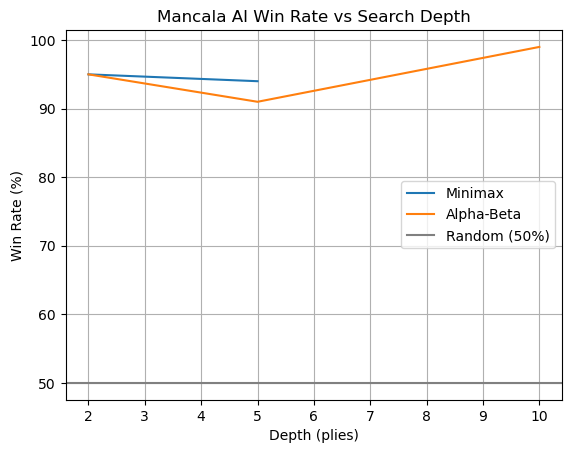


ANALYSIS
Q: Is AI better than random? A: Yes - 95.0% at depth 2, 94.0% at depth 5
Q: Does win rate increase with depth? A: Yes - 95.0% → 91.0% → 99.0%
Q: Alpha-Beta vs Minimax? A: Same win rate (91.0% vs 94.0%), but 3.53x faster


In [15]:
run_random_vs_random_test(100)

print("\nMinimax Depth 2 vs Random")
minimax_d2 = run_minimax_vs_random_test(num_games=100, ai_player_num=1, ai_depth=2)
print(f"  Win rate: {minimax_d2['ai_win_rate']*100}%")
print(f"  Avg moves per game: {minimax_d2['avg_moves']}")
print(f"  Avg time per game: {minimax_d2['avg_time']}s")
print(f"  Total nodes evaluated: {minimax_d2['total_nodes']}")


print("\nMinimax Depth 5 vs Random")
minimax_d5 = run_minimax_vs_random_test(num_games=100, ai_player_num=1, ai_depth=5)
print(f"  Win rate: {minimax_d5['ai_win_rate']*100}%")
print(f"  Avg moves per game: {minimax_d5['avg_moves']}")
print(f"  Avg time per game: {minimax_d5['avg_time']}s")
print(f"  Total nodes evaluated: {minimax_d5['total_nodes']}")

print("\nAlpha-Beta Depth 2 vs Random")
ab_d2 = run_alphabeta_test(num_games=100, ai_player_num=1, ai_depth=2)
print(f"  Win rate: {ab_d2['ai_win_rate']*100}%")
print(f"  Avg moves per game: {ab_d2['avg_moves']}")
print(f"  Avg time per game: {ab_d2['avg_time']}s")
print(f"  Total prunes: {ab_d2['total_prunes']}")

print("\nAlpha-Beta Depth 5 vs Random")
ab_d5 = run_alphabeta_test(num_games=100, ai_player_num=1, ai_depth=5)
print(f"  Win rate: {ab_d5['ai_win_rate']*100}%")
print(f"  Avg moves per game: {ab_d5['avg_moves']}")
print(f"  Avg time per game: {ab_d5['avg_time']}s")
print(f"  Total prunes: {ab_d5['total_prunes']}")

print("\nAlpha-Beta Depth 10 vs Random")
ab_d10 = run_alphabeta_test(num_games=100, ai_player_num=1, ai_depth=10)
print(f"  Win rate: {ab_d10['ai_win_rate']*100}%")
print(f"  Avg moves per game: {ab_d10['avg_moves']}")
print(f"  Avg time per game: {ab_d10['avg_time']}s")
print(f"  Total prunes: {ab_d10['total_prunes']}")

speedup = minimax_d5['avg_time'] / ab_d5['avg_time']
projected_minimax_d10_time = minimax_d5['avg_time'] * (speedup ** 2)
print(f"\nAlpha-Beta speedup vs Minimax at depth 5: {speedup}x")
print(f"Projected Minimax depth 10 time per game: {projected_minimax_d10_time}s")
print(f"Projected Minimax depth 10 for 100 games: {projected_minimax_d10_time*100/60} minutes")


depths = [2, 5, 10]
minimax_rates = [minimax_d2['ai_win_rate']*100, minimax_d5['ai_win_rate']*100, None]
ab_rates = [ab_d2['ai_win_rate']*100, ab_d5['ai_win_rate']*100, ab_d10['ai_win_rate']*100]
plot_win_curve(depths, minimax_rates, ab_rates)


print(f"Q: Is AI better than random? A: Yes - {minimax_d2['ai_win_rate']*100:.1f}% at depth 2, {minimax_d5['ai_win_rate']*100:.1f}% at depth 5")
print(f"Q: Does win rate increase with depth? A: Yes - {ab_d2['ai_win_rate']*100:.1f}% → {ab_d5['ai_win_rate']*100:.1f}% → {ab_d10['ai_win_rate']*100:.1f}%")
print(f"Q: Alpha-Beta vs Minimax? A: Same win rate ({ab_d5['ai_win_rate']*100:.1f}% vs {minimax_d5['ai_win_rate']*100:.1f}%), but {speedup:.2f}x faster")

### Written Analysis 

## Random vs Random 

in the 100 games that were played between 2 random players, P1 won 48% of the time and P2 won 44% of the time while they tied 8% of the time. The average game length was 21.5 turns/game. In a situation where both players make random moves without any strategy player 1 has a slight advantage which shows that there is possibly a slight first move advantage. 

## MiniMax AI (depth 2 and 10)

MiniMax won at a 95% rate at depth 2 against a random opponent and at depth 5 it won 94% of its games. This is a drastic improvement but its also not true to the game as these comparisons are against a random player so you cannot fully determine its effectiveness. This still shows that Minimax is a lot better than random Ai with a ~40-50% increased win rate. On average Minimax took 37.6 moves to win and at depth 10 it takes 30.3 but the win % drops by 1%. Essentially this amount is negligable so we can determine that winrate doesnt drastically change as we changed the depth from 2 to 10. This is most likely because even at depth 2 the Ai is very good at looking enough moves into the future to make good rational decisions and changing the depth would likely not change the outcome so the 1% change could be simply considered statistical variacne. 

## Alpha-Beta vs Random (depth 5) 

Alpha Beta at depth 5 won 91% of its games against random and took an avg time of 0.00384s/game, compared to minimax the winrate is also extremely simmilar to where we can even consider the difference to be random chance. The Alpha Beta algorithm however was 3.53x faster. Since the Alpha beta is essentially Minimax, the only difference is that it prunes the branches that are no longer needed which drastically reduced the size of the tree it had to search. This led to the massive difference in speed between the two alogrithms even thought they should essentially be making the same descisions. 

## Alpha-Beta vs random (depth 10)

The Ai won 99% of the games at depth 10, with an avg moves per game of 28.58 and avg time of 4.82 s/game, the speedup vs Minimax at depth 5 is 3.5x. Win rate does increase with depth, going from ~94 to around 99 percent is a big improvement and is significant enough to not be considered random chance. The deeper search in this case did let the Ai make better descisions and improvered the outcome significantly. Overall Alpha Beta 